Example Plots for Simulated Annealing

In [26]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [27]:
num_runs = 100

In [28]:
brute_force_data_paths = [
    'data/brute_force/candidate_space_1048576_instances_1_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_9_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_33_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_42_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_57_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_99_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_100_seed_2026-03-28_15-52-55.csv',
    'data/brute_force/candidate_space_1048576_instances_110_seed_2026-03-28_15-16-30.csv',
    'data/brute_force/candidate_space_1048576_instances_808_seed_2026-03-28_15-53-27.csv',
    'data/brute_force/candidate_space_1048576_instances_5004_seed_2026-03-28_15-16-30.csv',
]
boundss = [
    [(0, 4)] * 10
] * len(brute_force_data_paths)

In [29]:
import pandas as pd

brute_force_data = [pd.read_csv(p) for p in brute_force_data_paths]

In [30]:
from cl_optimizer import SimulatedAnnealing
sim_annss = [[
        SimulatedAnnealing(
        lookup_table=data,
        bounds=bounds,
    ) for _ in range(num_runs)
] for data, bounds in zip(brute_force_data, boundss)]

In [31]:
import numpy as np
# I think init and end temperatures should be chosen dependent on the delta of the energy,
# i.e. delta = new_loss - old_loss (in the exponent)
# larger delta -> larger temperature (and conversely smaller beta)
init_temp = 1000
end_temp = 1
max_temp_iterations = 101

def execute_sim_ann(df_id: int, sim_ann: SimulatedAnnealing, temp_iterations: list[int]) -> np.ndarray:
    optima = []
    for iterations in temp_iterations:
        print(f"Temp. Iterations {iterations}")
        temp_schedule = SimulatedAnnealing.geometric_temp_schedule(init_temp, end_temp, iterations)
        _, loss = sim_ann.optimize(
            temp_schedule=temp_schedule,
            verbose=False
        )
        optima.append(loss)

    return np.concat(([df_id], temp_iterations, optima))

In [32]:
from joblib import Parallel, delayed
from parallelization import construct_parallelization_arg_list
from parallelization import extract_sorted_losses_and_temps

sorted_tempss = []
sorted_lossess = []
for sim_anns in sim_annss:
    arg_list = construct_parallelization_arg_list(sim_anns, depth=max_temp_iterations, step=10, batch_size=8)

    print(f"Preparing to execute {len(arg_list)} in parallel.")
    results = np.array(
        Parallel(n_jobs=-1, verbose=11)(
        delayed(execute_sim_ann)(s_id, sim_ann, temp_iterations) for (s_id, sim_ann), temp_iterations in arg_list)
    )

    sorted_temps, sorted_losses = extract_sorted_losses_and_temps(results)
    sorted_tempss.append(sorted_temps)
    sorted_lossess.append(sorted_losses)

Preparing to execute 100 in parallel.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.3min
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  2.7min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  2

Preparing to execute 100 in parallel.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:  2.2min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  2.3min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  2.5min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  4.3min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  4.5min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  4.5min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  4.7min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  4.7min
[Paralle

Preparing to execute 100 in parallel.


...

[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.6min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  3.3min
[Paralle

Preparing to execute 100 in parallel.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  3.5min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  6.7min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  6.7min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  6.8min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  6.8min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  6.8min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  6.8min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  6.8min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  6.8min
[Paralle

Preparing to execute 100 in parallel.


[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  3.6min
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  3.7min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  3.8min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  7.1min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  7.1min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  7.1min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  7.2min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  7.3min
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:  7.3min
[Paralle

In [33]:
from datetime import datetime

cols = [f'loss (temperature={int(temp)})' for temp in sorted_tempss[0][0]]
df = pd.DataFrame(np.vstack(sorted_lossess), columns=cols)
df["data path"] = np.repeat(brute_force_data_paths, num_runs)
df.to_csv(f'data/simulated_annealing/summary_{datetime.now().strftime("%Y-%m-%d_%H-%M-%S")}.csv')

In [34]:
from metrics import raar

avg_loss_runs = [sorted_losses.mean(axis=0) for sorted_losses in sorted_lossess]
raars = np.array([[raar(avg, brute_force_data[i]['loss']) for avg in avg_loss] for i, avg_loss in enumerate(avg_loss_runs)])
mean_raar = raars.mean(axis=0)
std_raar = raars.std(axis=0)

<Axes: xlabel='temperature iterations', ylabel='RAAR'>

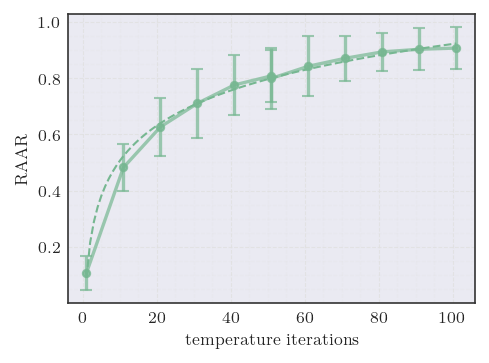

In [56]:
import styling
import matplotlib.pyplot as plt
import seaborn as sns

styling.set_my_style()

df = pd.DataFrame()
df["temperature iterations"] = sorted_tempss[0][0, :].astype(int)
df["RAAR"] = mean_raar
df["RAAR_std"] = std_raar

palette = styling.shades(6, 4)[1:]
palette = sns.color_palette("crest", 5)


fig, ax = styling.subplots(figsize=(3.5, 2.5))

line = plt.plot(
    df["temperature iterations"],
    df["RAAR"],
    alpha=0.7,
    linewidth=1.6,
    markersize=3.5,
    color=palette[0]
)


ax.errorbar(
    x=df["temperature iterations"],
    y=df["RAAR"],
    yerr=df["RAAR_std"],
    fmt="none",
    capsize=3,
    color=palette[0],
    alpha=0.7,
    linewidth=1.6
)

sns.regplot(x=df["temperature iterations"], y=df["RAAR"], color=palette[0], ax=ax, line_kws={'linestyle': "--", 'linewidth': 1.0}, ci=None, logx=True)

In [49]:
df["temperature iterations"]

0       1
1      11
2      21
3      31
4      41
5      51
6      51
7      61
8      71
9      81
10     91
11    101
Name: temperature iterations, dtype: int64

In [36]:
min_losses = [data['loss'].min() for data in brute_force_data]
min_loss_candidates = np.array([data[data['loss'] == min_loss]['candidate'] for data, min_loss in zip(brute_force_data, min_losses)])

In [37]:
min_loss_candidates

array([['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]'],
       ['[0 0 0 0 0 0 0 0 0 0]']], dtype=object)

In [38]:
optimal_candidates_found = [np.count_nonzero(sorted_losses == min_loss, axis=0) for sorted_losses, min_loss in zip(sorted_lossess, min_losses)]
p_star = [optimal_found / sorted_losses.shape[1] for optimal_found, sorted_losses in zip(optimal_candidates_found, sorted_lossess)]

In [39]:
from metrics import min_tts
tts_ps = np.array([min_tts(p_s, return_tts_p=True)[2] for p_s in p_star])

In [42]:
tts_ps

array([[4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06,
        4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06,
        4.605168e+06, 5.300000e+01, 4.605168e+06, 4.605168e+06],
       [4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06,
        4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06,
        4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06],
       [4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06,
        4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06,
        4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06],
       [4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06,
        4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06,
        4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06],
       [4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06,
        4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06,
        4.605168e+06, 4.605168e+06, 4.605168e+06, 4.605168e+06],
       [4.605168e+06, 4.605168e+06,

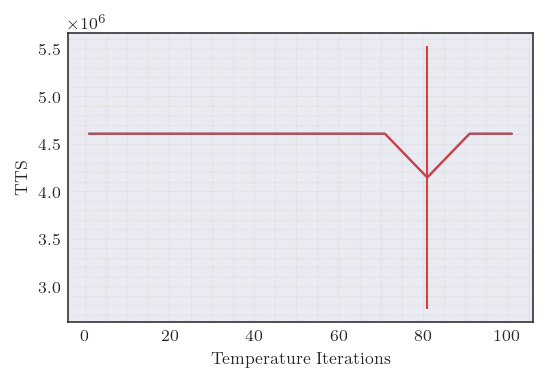

In [40]:
from matplotlib import pyplot as plt

mean_tts_ps = tts_ps.mean(axis=0)
std_tts_ps = tts_ps.std(axis=0)

plt.plot(
    sorted_tempss[0][0, :],
    mean_tts_ps,
)

plt.errorbar(
    sorted_tempss[0][0, :],
    y=mean_tts_ps,
    yerr=std_tts_ps,
)
plt.ylabel('TTS')
plt.xlabel('Temperature Iterations')
plt.grid(visible=True)